In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
data = pd.read_csv(r"C:\Users\Vamsi Krishna\OneDrive\Documents\vehicle_maintenance_data - Copy.csv")

data.head()

,Vehicle_Type,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,...,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance,Today
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,23-11-2023,...,Second,20782,6,3,13.622204,New,New,Weak,1,15-06-2025
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,21-09-2023,...,Second,23489,7,0,13.625307,New,New,Weak,1,15-06-2025
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,27-06-2023,...,First,17979,7,0,14.306302,New,Good,Weak,1,15-06-2025
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,24-08-2023,...,Second,6220,7,3,18.709467,New,Worn Out,New,1,15-06-2025
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,25-05-2023,...,Third,16446,6,2,16.977483,Good,Good,Weak,1,15-06-2025


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Vehicle_Type             50000 non-null  object 
 1   Mileage                  50000 non-null  int64  
 2   Maintenance_History      50000 non-null  object 
 3   Reported_Issues          50000 non-null  int64  
 4   Vehicle_Age              50000 non-null  int64  
 5   Fuel_Type                50000 non-null  object 
 6   Transmission_Type        50000 non-null  object 
 7   Engine_Size              50000 non-null  int64  
 8   Odometer_Reading         50000 non-null  int64  
 9   Last_Service_Date        50000 non-null  object 
 10  Days_Since_Last_Service  50000 non-null  int64  
 11  Warranty_Expiry_Date     50000 non-null  object 
 12  Owner_Type               50000 non-null  object 
 13  Insurance_Premium        50000 non-null  int64  
 14  Service_History       

In [5]:
data.isnull().sum()

Vehicle_Type               0
Mileage                    0
Maintenance_History        0
Reported_Issues            0
Vehicle_Age                0
Fuel_Type                  0
Transmission_Type          0
Engine_Size                0
Odometer_Reading           0
Last_Service_Date          0
Days_Since_Last_Service    0
Warranty_Expiry_Date       0
Owner_Type                 0
Insurance_Premium          0
Service_History            0
Accident_History           0
Fuel_Efficiency            0
Tire_Condition             0
Brake_Condition            0
Battery_Status             0
Need_Maintenance           0
Today                      0
dtype: int64

In [6]:
data.describe()

,Mileage,Reported_Issues,Vehicle_Age,Engine_Size,Odometer_Reading,Days_Since_Last_Service,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Need_Maintenance
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,54931.232680,2.497420,5.492260,1556.292000,75551.187060,640.559860,17465.340700,5.515560,1.50156,14.990323,0.809960
std,14401.912925,1.708781,2.875682,627.677218,43088.105658,96.938327,7223.393401,2.874899,1.11951,2.885583,0.392336
min,30001.000000,0.000000,1.000000,800.000000,1001.000000,473.000000,5000.000000,1.000000,0.00000,10.000098,0.000000
25%,42471.500000,1.000000,3.000000,1000.000000,38009.000000,557.000000,11189.750000,3.000000,0.00000,12.489037,1.000000
50%,54810.000000,2.000000,5.000000,1500.000000,75598.500000,640.000000,17477.500000,6.000000,2.00000,14.986352,1.000000
75%,67391.500000,4.000000,8.000000,2000.000000,112999.500000,725.000000,23692.000000,8.000000,3.00000,17.474676,1.000000
max,80000.000000,5.000000,10.000000,2500.000000,149999.000000,808.000000,30000.000000,10.000000,3.00000,19.999968,1.000000


In [7]:
label_encoder = LabelEncoder()

for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = label_encoder.fit_transform(data[column])

data.head()

,Vehicle_Type,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,...,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance,Today
0,4,58765,1,0,4,1,0,2000,28524,251,...,1,20782,6,3,13.622204,1,1,2,1,0
1,5,60353,0,1,7,1,0,2500,133630,227,...,1,23489,7,0,13.625307,1,1,2,1,0
2,0,68072,2,0,2,1,0,1500,34022,290,...,0,17979,7,0,14.306302,1,0,2,1,0
3,0,60849,0,4,5,2,0,2500,81636,259,...,1,6220,7,3,18.709467,1,2,1,1,0
4,0,45742,2,5,1,2,1,2000,97162,267,...,2,16446,6,2,16.977483,0,0,2,1,0


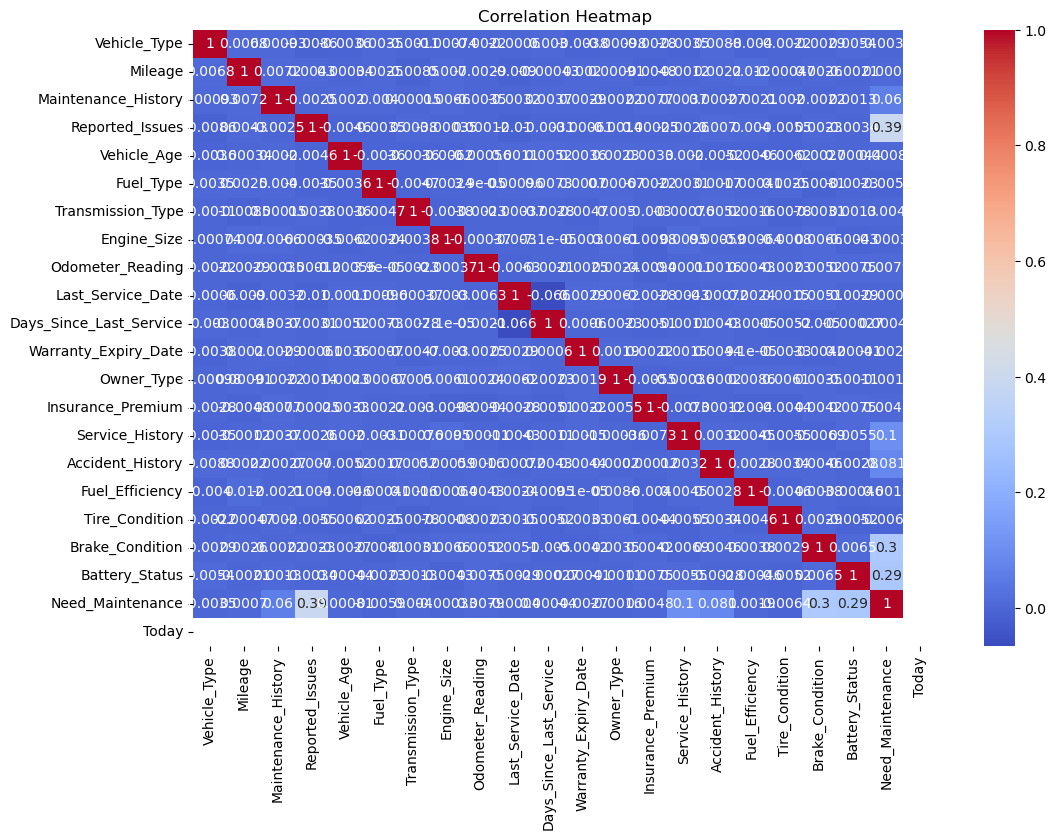

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [9]:
X = data.drop("Need_Maintenance", axis=1)
y = data["Need_Maintenance"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)

In [13]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_predictions))
print(confusion_matrix(y_test, log_predictions))
print(classification_report(y_test, log_predictions))

Logistic Regression Accuracy: 0.8872
[[1158  757]
 [ 371 7714]]
              precision    recall  f1-score   support

           0       0.76      0.60      0.67      1915
           1       0.91      0.95      0.93      8085

    accuracy                           0.89     10000
   macro avg       0.83      0.78      0.80     10000
weighted avg       0.88      0.89      0.88     10000



In [14]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_predictions))

Decision Tree Accuracy: 1.0


In [15]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

Random Forest Accuracy: 1.0


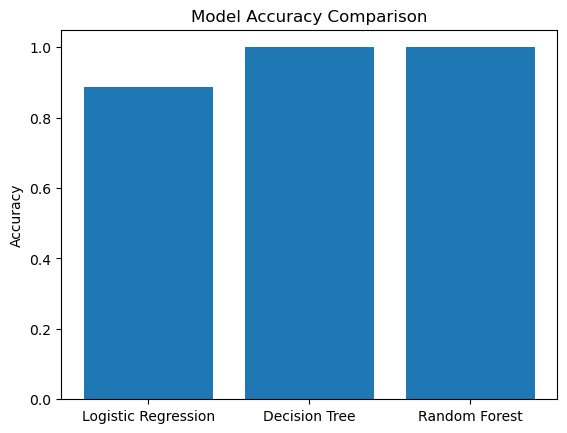

In [16]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
scores = [
    accuracy_score(y_test, log_predictions),
    accuracy_score(y_test, dt_predictions),
    accuracy_score(y_test, rf_predictions)
]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [17]:
feature_importance = rf_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
3,Reported_Issues,0.293852
19,Battery_Status,0.217982
18,Brake_Condition,0.203905
14,Service_History,0.064251
2,Maintenance_History,0.062917
15,Accident_History,0.042637
1,Mileage,0.012966
8,Odometer_Reading,0.012804
16,Fuel_Efficiency,0.012772
13,Insurance_Premium,0.012687


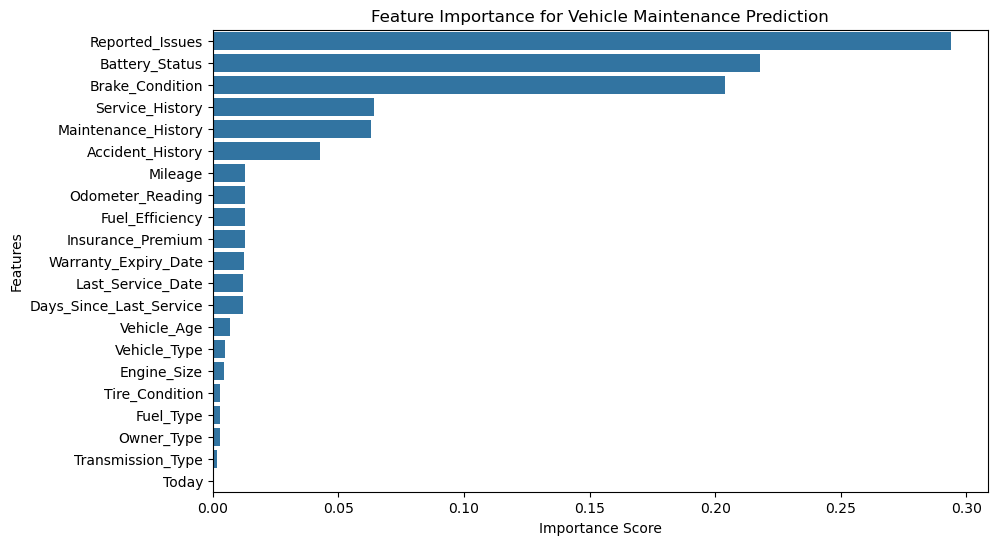

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=importance_df['Importance'],
    y=importance_df['Feature']
)

plt.title("Feature Importance for Vehicle Maintenance Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

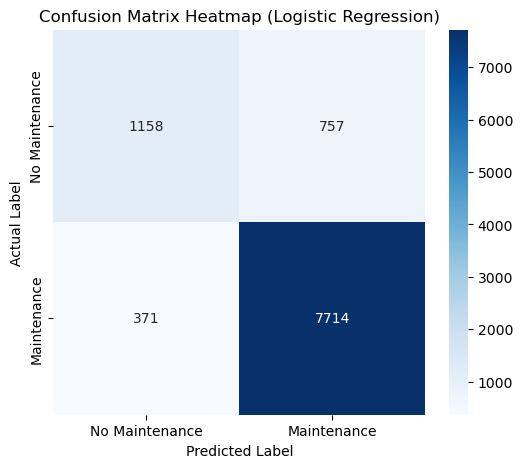

In [19]:
cm = confusion_matrix(y_test, log_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['No Maintenance','Maintenance'],
            yticklabels=['No Maintenance','Maintenance'])

plt.title("Confusion Matrix Heatmap (Logistic Regression)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

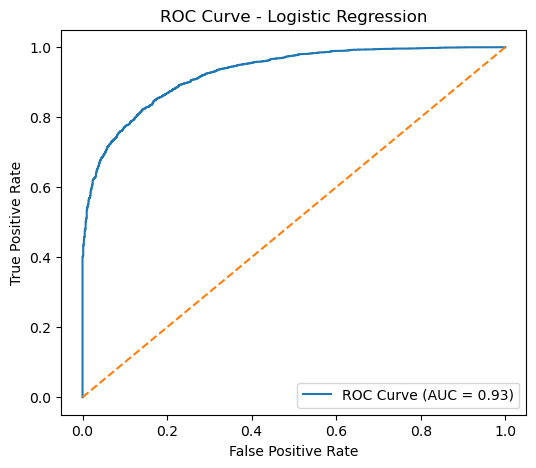

In [20]:
from sklearn.metrics import roc_curve, auc

y_prob = log_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

In [22]:
data.to_csv("vehicle_maintenance_cleaned.csv", index=False)